# 12-Month Time-Series Momentum on the S&P 500

Does a positive return over the previous 12 months predict stronger future returns? Can a simple monthly timing rule improve the balance between return and risk?

This project studies the S&P 500 Total Return Index, then applies the same signal to SPY. The main finding is cautious: the return difference is not statistically significant after HAC correction. Historically, the strategy's more consistent benefit was lower risk, while its return advantage varied across subperiods.

The notebook follows the original research: data, statistical analysis, HAC inference, a backtest, risk-free returns, lookback robustness, SPY implementation, transaction costs, subperiods, and visualizations.


## 1. Research question and hypothesis

The initial question is whether a positive 12-month return is followed by stronger returns over the next three months than a nonpositive 12-month return. A one-month horizon is also studied and used for the trading strategy.

- **Null hypothesis:** average forward returns are the same after positive and nonpositive 12-month returns.
- **Directional hypothesis:** average forward returns are higher after positive 12-month returns.

The Welch test below is one-sided. The regression p-values reported by statsmodels are two-sided. The tests do not establish that returns after a nonpositive signal must be negative.


## 2. Data and setup

| Input | Role | Original snapshot |
| --- | --- | --- |
| S&P 500 Total Return Index (`^SP500TR`), downloaded with yfinance | Signal and initial analysis, using `Close` | January 1988–July 2026 |
| SPY, downloaded with yfinance using `auto_adjust=False` | Tradable proxy, using `Adj Close` | January 1993–July 2026 |
| `RF` in `F-F_Research_Data_Factors.csv` | Monthly risk-free return | File ending in July 2026 |

Daily prices are resampled to the last available observation in each calendar month. The analysis uses the original fixed CSV files; it does not download an updated sample.

Run this notebook from the repository root or the `notebooks/` folder. All three original CSV snapshots are included in `data/`. The Python environment is listed in `requirements.txt`.

**Reproduction status:** all research calculations were rerun from the three original CSV snapshots. The key results are reproducible from the fixed input files included with the project.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import plotly.graph_objects as go
import plotly.io as pio

# Interactive figures in Jupyter; saved PNG previews are also included for GitHub.
pio.renderers.default = "plotly_mimetype+notebook_connected"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"


In [2]:
df_sp500 = pd.read_csv(
    DATA_DIR / "sp500tr_daily_1988_2026-07.csv",
    index_col="Date",
    parse_dates=["Date"],
)
df_sp500.index = pd.to_datetime(df_sp500.index, utc=True)
df_sp500.index = df_sp500.index.tz_localize(None)


In [3]:
print("Daily data shape:", df_sp500.shape)
print("Missing values:", df_sp500.isna().sum().sum())
print("Dates sorted:", df_sp500.index.is_monotonic_increasing)
print("Duplicate dates:", df_sp500.index.duplicated().sum())


Daily data shape: (9717, 7)
Missing values: 0
Dates sorted: True
Duplicate dates: 0


In [4]:
df_sp500 = df_sp500.resample("M").last()

df_sp500 = df_sp500.drop(columns=["Open", "High", "Low", "Volume", "Dividends", "Stock Splits"])

df_sp500["return_12m"] = df_sp500["Close"] / df_sp500["Close"].shift(12) - 1

df_sp500["future_return_3m"] = df_sp500["Close"].shift(-3) / df_sp500["Close"] - 1

df_sp500["future_return_1m"] = df_sp500["Close"].shift(-1) / df_sp500["Close"] - 1

df_sp500.head()


,Close,return_12m,future_return_3m,future_return_1m
Date,,,,
1988-01-31,257.470001,NaN,0.025518,0.046646
1988-02-29,269.480011,NaN,-0.011726,-0.030911
1988-03-31,261.149994,NaN,0.066590,0.011066
1988-04-30,264.040009,NaN,0.050939,0.008635
1988-05-31,266.320007,NaN,0.006571,0.045885


### Forward returns and the usable samples

The signal uses the trailing 12-month total return, $P_t/P_{t-12}-1$. Forward returns are $P_{t+h}/P_t-1$, for $h=1$ or $h=3$ months.

Missing observations are removed before calculating probabilities. This avoids treating an unavailable forward return as a nonpositive return. The three-month sample has 448 observations; the one-month sample has 450.


In [5]:
analysis_df = df_sp500[["Close", "return_12m", "future_return_3m"]].dropna().copy()

analysis_1m_df = df_sp500[["Close", "return_12m", "future_return_1m"]].dropna().copy()

print("Three-month sample:", analysis_df.shape)
print("One-month sample:", analysis_1m_df.shape)


Three-month sample: (448, 3)
One-month sample: (450, 3)


## 3. Descriptive statistics and the one-month test

The tables compare average forward returns and the fraction of positive forward returns. Positive 12-month returns are associated with stronger subsequent returns in this sample, but descriptive differences alone do not establish statistical significance.


In [6]:
mean_3m = analysis_df[analysis_df["return_12m"] > 0]["future_return_3m"].mean()

probability_3m = (analysis_df[analysis_df["return_12m"] > 0]["future_return_3m"] > 0).mean()

mean_3m_benchmark = analysis_df["future_return_3m"].mean()

probability_3m_benchmark = (analysis_df["future_return_3m"] > 0).mean()

mean_3m_neg = analysis_df[analysis_df["return_12m"] <= 0]["future_return_3m"].mean()

probability_3m_neg = (
    analysis_df[analysis_df["return_12m"] <= 0]["future_return_3m"] > 0
).mean()


pd.DataFrame(
    {
        "Mean forward return": [mean_3m, mean_3m_neg, mean_3m_benchmark],
        "Probability of a positive return": [
            probability_3m,
            probability_3m_neg,
            probability_3m_benchmark,
        ],
    },
    index=["Positive 12-month return", "Nonpositive 12-month return", "All observations"],
).style.format("{:.2%}")


,Mean forward return,Probability of a positive return
Positive 12-month return,3.37%,75.40%
Nonpositive 12-month return,1.01%,58.11%
All observations,2.98%,72.54%


In [7]:
mean_1m = analysis_1m_df[analysis_1m_df["return_12m"] > 0]["future_return_1m"].mean()

probability_1m = (
    analysis_1m_df[analysis_1m_df["return_12m"] > 0]["future_return_1m"] > 0
).mean()

mean_1m_benchmark = analysis_1m_df["future_return_1m"].mean()

probability_1m_benchmark = (analysis_1m_df["future_return_1m"] > 0).mean()

mean_1m_neg = analysis_1m_df[analysis_1m_df["return_12m"] <= 0]["future_return_1m"].mean()
probability_1m_neg = (
    analysis_1m_df[analysis_1m_df["return_12m"] <= 0]["future_return_1m"] > 0
).mean()

std_1m_positive_12m = (
    analysis_1m_df[analysis_1m_df["return_12m"] > 0]["future_return_1m"]
).std()
std_1m_nonpositive_12m = (
    analysis_1m_df[analysis_1m_df["return_12m"] <= 0]["future_return_1m"]
).std()

n_1m_positive_12m = (
    analysis_1m_df[analysis_1m_df["return_12m"] > 0]["future_return_1m"]
).count()
n_1m_nonpositive_12m = (
    analysis_1m_df[analysis_1m_df["return_12m"] <= 0]["future_return_1m"]
).count()

pd.DataFrame(
    {
        "Mean forward return": [mean_1m, mean_1m_neg, mean_1m_benchmark],
        "Probability of a positive return": [
            probability_1m,
            probability_1m_neg,
            probability_1m_benchmark,
        ],
    },
    index=["Positive 12-month return", "Nonpositive 12-month return", "All observations"],
).style.format("{:.2%}")


,Mean forward return,Probability of a positive return
Positive 12-month return,1.12%,67.82%
Nonpositive 12-month return,0.30%,55.41%
All observations,0.98%,65.78%


### Welch test

The one-month sample contains 376 positive-signal observations and 74 nonpositive-signal observations. Their average forward returns are about 1.12% and 0.30%, respectively.

The following calculation keeps the original manual Welch test, followed by the scipy check. It allows different variances across the two groups but does not account for time-series dependence.


In [8]:
se_1m_positive_12m = (std_1m_positive_12m) / np.sqrt(n_1m_positive_12m)
se_1m_nonpositive_12m = (std_1m_nonpositive_12m) / np.sqrt(n_1m_nonpositive_12m)

se_diff_1m = np.sqrt((se_1m_positive_12m**2) + (se_1m_nonpositive_12m**2))

t_statistic = (mean_1m - mean_1m_neg) / se_diff_1m

df_welch = (
    (
        ((std_1m_positive_12m**2) / n_1m_positive_12m)
        + ((std_1m_nonpositive_12m**2) / n_1m_nonpositive_12m)
    )
    ** 2
) / (
    (((std_1m_positive_12m**2) / n_1m_positive_12m) ** 2 / (n_1m_positive_12m - 1))
    + (((std_1m_nonpositive_12m**2) / n_1m_nonpositive_12m) ** 2 / (n_1m_nonpositive_12m - 1))
)

p_value_1m = stats.t.sf(t_statistic, df=df_welch)

pd.Series(
    {
        "t-statistic": t_statistic,
        "Degrees of freedom": df_welch,
        "One-sided p-value": p_value_1m,
    }
)


t-statistic            1.106426
Degrees of freedom    83.889806
One-sided p-value      0.135853
dtype: float64

In [9]:
positive_1m = analysis_1m_df.loc[analysis_1m_df["return_12m"] > 0, "future_return_1m"]

nonpositive_1m = analysis_1m_df.loc[analysis_1m_df["return_12m"] <= 0, "future_return_1m"]

stats.ttest_ind(positive_1m, nonpositive_1m, equal_var=False, alternative="greater")


TtestResult(statistic=1.106425576747293, pvalue=0.13585255084579406, df=83.88980601834777)

The one-sided p-value is about 0.136, so the difference is not significant at the 5% level. The next section examines time-series dependence and uses HAC standard errors.


## 4. Time-series dependence and HAC inference

The regression is

$$R_{t+1}=\alpha+\beta S_t+\varepsilon_{t+1},\qquad S_t=1\{R_{t-12,t}>0\}.$$

The constant is the average forward return when the signal is zero. The signal coefficient is the difference between the two group means.


In [10]:
analysis_1m_df["signal"] = (analysis_1m_df["return_12m"] > 0).astype(int)

return_autocorr_1 = analysis_1m_df["future_return_1m"].autocorr(lag=1)

signal_autocorr_1 = analysis_1m_df["signal"].autocorr(lag=1)

return_autocorr_1, signal_autocorr_1


(-0.00984613590093637, 0.8381981981981981)

In [11]:
y = analysis_1m_df["future_return_1m"]
x = analysis_1m_df["signal"]

X = sm.add_constant(x)

model = sm.OLS(y, X)

results = model.fit()

results.params


const     0.002953
signal    0.008215
dtype: float64

In [12]:
for lag in range(1, 7):
    print(lag)
    print(results.resid.autocorr(lag=lag))

sm.stats.diagnostic.acorr_ljungbox(results.resid)


1
-0.026931988852050323
2
-0.07400744122159564
3
0.036410627624712394
4
-0.00024490120627932045
5
0.004054494827118771
6
-0.0997460933013312


,lb_stat,lb_pvalue
1,0.327961,0.566862
2,2.808270,0.245579
3,3.407492,0.332960
4,3.407516,0.492079
5,3.414865,0.636307
6,7.827498,0.251016
7,9.603523,0.212177
8,11.604539,0.169740
9,13.971696,0.123336
10,13.972522,0.174249


The Ljung–Box test does not reject the null of no residual autocorrelation at the reported lags. Squared residuals show clear dependence, consistent with volatility clustering. This motivates standard errors that allow heteroskedasticity and autocorrelation.


In [13]:
((results.resid) ** 2).autocorr(lag=1)

sm.stats.diagnostic.acorr_ljungbox(results.resid**2)


,lb_stat,lb_pvalue
1,31.084472,2.470397e-08
2,36.908443,9.670155e-09
3,46.678398,4.068502e-10
4,53.960353,5.364245e-11
5,59.955963,1.241194e-11
6,65.230101,3.871553e-12
7,66.961324,6.061594e-12
8,67.052873,1.892650e-11
9,68.088926,3.604046e-11
10,69.555750,5.401526e-11


### One-month regression with HAC standard errors

The main specification uses six lags. HAC changes the estimated uncertainty, not the regression coefficients. The signal coefficient remains positive, but the two-sided p-value is about 0.314.


In [14]:
results_hac = model.fit(cov_type="HAC", cov_kwds={"maxlags": 6})


pd.DataFrame(
    {
        "Coefficient": results_hac.params,
        "OLS standard error": results.bse,
        "HAC standard error": results_hac.bse,
        "HAC statistic": results_hac.tvalues,
        "HAC two-sided p-value": results_hac.pvalues,
    }
)


,Coefficient,OLS standard error,HAC standard error,HAC statistic,HAC two-sided p-value
const,0.002953,0.004923,0.007934,0.372167,0.709769
signal,0.008215,0.005386,0.008164,1.006313,0.314265


The original sensitivity check uses 1, 3, 6, and 12 HAC lags. Each line reports the lag choice, standard error, statistic, and two-sided p-value. The conclusion is unchanged.


In [15]:
for maxlag in 1, 3, 6, 12:
    results_hac_temp = model.fit(cov_type="HAC", cov_kwds={"maxlags": maxlag})

    print(
        maxlag,
        results_hac_temp.bse["signal"],
        results_hac_temp.tvalues["signal"],
        results_hac_temp.pvalues["signal"],
    )


1 0.007846762609811061 1.0469461113010075 0.29512443304713787
3 0.007874523345606461 1.0432552219465345 0.29683010381312347
6 0.008163599966545471 1.006313101365766 0.31426498017950266
12 0.00745987189936312 1.1012437896346714 0.27079056802605206


### Three-month forward returns

Adjacent three-month returns overlap, so they share two months of returns. This creates strong dependence. The ordinary OLS result is shown first, followed by HAC with two lags and the original checks at 3, 6, and 12 lags.


In [16]:
for lag in range(1, 7):
    print(analysis_df["future_return_3m"].autocorr(lag=lag))


0.6681323292959889
0.33502782533673336
0.03330918592668938
0.019627629865373242
0.024905364215063883
0.028433314605450614


In [17]:
analysis_df["signal"] = (analysis_df["return_12m"] > 0).astype(int)
y_3m = analysis_df["future_return_3m"]
x_3m = analysis_df["signal"]
X_3m = sm.add_constant(x_3m)
model_3m = sm.OLS(y_3m, X_3m)

results_3m = model_3m.fit()


results_3m.bse, results_3m.tvalues, results_3m.pvalues


(const     0.008353
 signal    0.009142
 dtype: float64,
 const     1.205570
 signal    2.589004
 dtype: float64,
 const     0.228622
 signal    0.009940
 dtype: float64)

In [18]:
results_3m_hac = model_3m.fit(cov_type="HAC", cov_kwds={"maxlags": 2})

results_3m_hac.params["signal"], results_3m_hac.bse["signal"], results_3m_hac.tvalues[
    "signal"
], results_3m_hac.pvalues["signal"]


(0.023668121550619002,
 0.019224515258320595,
 1.2311426963223513,
 0.21826949907083826)

In [19]:
for maxlag in 3, 6, 12:
    results_3m_hac = model_3m.fit(cov_type="HAC", cov_kwds={"maxlags": maxlag})
    print(
        maxlag,
        results_3m_hac.params["signal"],
        results_3m_hac.bse["signal"],
        results_3m_hac.tvalues["signal"],
        results_3m_hac.pvalues["signal"],
    )


3 0.023668121550619002 0.020612361402051915 1.1482489118526173 0.2508658226954359
6 0.023668121550619002 0.022659781104998528 1.0444991256070892 0.29625452353964865
12 0.023668121550619002 0.02134530346685185 1.1088210381911117 0.26750739281968927


### Statistical finding

Average three-month forward returns are about 2.37 percentage points higher after positive 12-month returns. Ordinary OLS gives a two-sided p-value of about 0.010, but HAC with two lags raises it to about 0.218. The other tested lag choices also give p-values above 0.05.

The observed difference is positive, but the sample does not provide sufficient statistical evidence to reject the null after accounting for time-series dependence.


## 5. Monthly backtest

The strategy holds the index when the trailing 12-month return is positive and otherwise stays out of the market. The first version assumes a zero return while out of the market. The benchmark holds the index throughout. There is no short selling or leverage.

Rows are indexed by the **decision date** t. A forward return on row t is earned from t to t+1. Wealth and drawdowns recorded on that row therefore describe the end of the following month. This convention is retained throughout, including the charts.


In [20]:
analysis_1m_df["strategy_return"] = (
    analysis_1m_df["future_return_1m"] * analysis_1m_df["signal"]
)

analysis_1m_df["strategy_wealth"] = (analysis_1m_df["strategy_return"] + 1).cumprod()

analysis_1m_df["benchmark_wealth"] = (analysis_1m_df["future_return_1m"] + 1).cumprod()

analysis_1m_df[["strategy_wealth", "benchmark_wealth"]].tail()


,strategy_wealth,benchmark_wealth
Date,,
2026-02-28,43.575551,47.090167
2026-03-31,48.147785,52.031176
2026-04-30,50.681950,54.769736
2026-05-31,50.199294,54.248151
2026-06-30,50.167420,54.213707


### Growth and volatility

Wealth starts at 1 and compounds monthly. Annualized growth is $W_{\mathrm{final}}^{12/N}-1$, where $N$ is the number of monthly returns. Annualized volatility is the sample standard deviation of monthly returns multiplied by $\sqrt{12}$.


In [21]:
T_years = len(analysis_1m_df) / 12

strategy_cagr = ((analysis_1m_df["strategy_wealth"].iloc[-1]) ** (1 / T_years)) - 1

benchmark_cagr = ((analysis_1m_df["benchmark_wealth"].iloc[-1]) ** (1 / T_years)) - 1

strategy_vol = analysis_1m_df["strategy_return"].std() * np.sqrt(12)
benchmark_vol = analysis_1m_df["future_return_1m"].std() * np.sqrt(12)


pd.DataFrame(
    {
        "CAGR": [strategy_cagr, benchmark_cagr],
        "Annualized volatility": [strategy_vol, benchmark_vol],
    },
    index=["Strategy, zero cash return", "Index buy and hold"],
).style.format("{:.2%}")


,CAGR,Annualized volatility
"Strategy, zero cash return",11.01%,11.94%
Index buy and hold,11.24%,14.69%


With zero cash returns, the strategy has slightly lower CAGR than the benchmark, but also lower volatility. The next step includes the return earned while out of the market.


## 6. Risk-free returns and lookback robustness

### Add the monthly risk-free return

The `RF` column contains monthly returns in percent. It is divided by 100 and shifted by one month to align the return earned over t→t+1 with the decision date t. It is used for cash returns and for the Sharpe ratio; it is not used to form the trading signal.

The original loader reads the 1,201 monthly rows in the fixed July 2026 file. An earlier, unused idea based on an annual Treasury yield is not part of the final calculation.


In [22]:
df_RF = pd.read_csv(
    DATA_DIR / "F-F_Research_Data_Factors.csv",
    usecols=["Unnamed: 0", "RF"],
    header=3,
    nrows=1201,
    index_col=0,
)
df_RF.index = pd.to_datetime(df_RF.index, format="%Y" + "%m") + pd.offsets.MonthEnd(1)
df_RF["RF"] = df_RF["RF"] / 100
df_RF["future_RF_1m"] = df_RF["RF"].shift(-1)
df_RF.tail()


,RF,future_RF_1m
2026-03-31,0.0029,0.0029
2026-04-30,0.0029,0.0031
2026-05-31,0.0031,0.0029
2026-06-30,0.0029,0.0033
2026-07-31,0.0033,NaN


In [23]:
backtest_df = pd.merge(
    analysis_1m_df, df_RF["future_RF_1m"], left_index=True, right_index=True, how="inner"
)

backtest_df["strategy_return"] = (
    backtest_df["signal"] * backtest_df["future_return_1m"]
    + (1 - backtest_df["signal"]) * backtest_df["future_RF_1m"]
)

backtest_df["strategy_wealth"] = (1 + backtest_df["strategy_return"]).cumprod()

backtest_df["benchmark_wealth"] = (1 + backtest_df["future_return_1m"]).cumprod()

backtest_df[["strategy_wealth", "benchmark_wealth"]].tail()


,strategy_wealth,benchmark_wealth
2026-02-28,50.077014,47.090167
2026-03-31,55.331423,52.031176
2026-04-30,58.243685,54.769736
2026-05-31,57.689017,54.248151
2026-06-30,57.652388,54.213707


### Performance measures

The annualized Sharpe ratio is $\sqrt{12}\,\overline{R_p-R_f}/s(R_p-R_f)$, using monthly excess returns. Maximum drawdown is the lowest wealth-to-running-peak ratio minus one. The original drawdown calculation uses observed end-of-month wealth values.


In [24]:
T_years_backtest = len(backtest_df) / 12

backtest_strategy_cagr = (
    (backtest_df["strategy_wealth"].iloc[-1]) ** (1 / T_years_backtest)
) - 1

backtest_benchmark_cagr = (
    (backtest_df["benchmark_wealth"].iloc[-1]) ** (1 / T_years_backtest)
) - 1

backtest_strategy_vol = backtest_df["strategy_return"].std() * np.sqrt(12)
backtest_benchmark_vol = backtest_df["future_return_1m"].std() * np.sqrt(12)

backtest_df["strategy_excess_return"] = (
    backtest_df["strategy_return"] - backtest_df["future_RF_1m"]
)
backtest_df["benchmark_excess_return"] = (
    backtest_df["future_return_1m"] - backtest_df["future_RF_1m"]
)

strategy_excess_return_mean = backtest_df["strategy_excess_return"].mean()
benchmark_excess_return_mean = backtest_df["benchmark_excess_return"].mean()

strategy_excess_return_vol = backtest_df["strategy_excess_return"].std()
benchmark_excess_return_vol = backtest_df["benchmark_excess_return"].std()

strategy_sharpe_monthly = strategy_excess_return_mean / strategy_excess_return_vol
benchmark_sharpe_monthly = benchmark_excess_return_mean / benchmark_excess_return_vol

strategy_sharpe_annualy = strategy_sharpe_monthly * np.sqrt(12)
benchmark_sharpe_annualy = benchmark_sharpe_monthly * np.sqrt(12)

backtest_df["peak_strategy"] = backtest_df["strategy_wealth"].cummax()
backtest_df["peak_benchmark"] = backtest_df["benchmark_wealth"].cummax()

backtest_df["DD_strategy"] = (backtest_df["strategy_wealth"] / backtest_df["peak_strategy"]) - 1
backtest_df["DD_benchmark"] = (
    backtest_df["benchmark_wealth"] / backtest_df["peak_benchmark"]
) - 1

MDD_strategy = backtest_df["DD_strategy"].min()
MDD_benchmark = backtest_df["DD_benchmark"].min()

pd.DataFrame(
    {
        "CAGR": [backtest_strategy_cagr, backtest_benchmark_cagr],
        "Annualized volatility": [backtest_strategy_vol, backtest_benchmark_vol],
        "Sharpe ratio": [strategy_sharpe_annualy, benchmark_sharpe_annualy],
        "Maximum drawdown": [MDD_strategy, MDD_benchmark],
    },
    index=["Strategy with RF", "Index buy and hold"],
).style.format(
    {
        "CAGR": "{:.2%}",
        "Annualized volatility": "{:.2%}",
        "Sharpe ratio": "{:.3f}",
        "Maximum drawdown": "{:.2%}",
    }
)


,CAGR,Annualized volatility,Sharpe ratio,Maximum drawdown
Strategy with RF,11.42%,11.92%,0.735,-19.60%
Index buy and hold,11.24%,14.69%,0.609,-50.95%


### Lookback windows: 6, 9, 12, and 18 months

The original comparison recalculates all four signals and uses a common sample beginning on July 31, 1990. This removes the unavailable lookback observations before comparing performance. All windows use the same index returns and risk-free series, without transaction costs.

The 12-month rule was the original research choice. Comparing these windows is a sensitivity check, not an independent out-of-sample test.


In [25]:
analysis_1m_df["return_6m"] = analysis_1m_df["Close"] / analysis_1m_df["Close"].shift(6) - 1
analysis_1m_df["return_9m"] = analysis_1m_df["Close"] / analysis_1m_df["Close"].shift(9) - 1
analysis_1m_df["return_12m"] = analysis_1m_df["Close"] / analysis_1m_df["Close"].shift(12) - 1
analysis_1m_df["return_18m"] = analysis_1m_df["Close"] / analysis_1m_df["Close"].shift(18) - 1

analysis_1m_df["signal_6m"] = (analysis_1m_df["return_6m"] > 0).astype(int)
analysis_1m_df["signal_9m"] = (analysis_1m_df["return_9m"] > 0).astype(int)
analysis_1m_df["signal_12m"] = (analysis_1m_df["return_12m"] > 0).astype(int)
analysis_1m_df["signal_18m"] = (analysis_1m_df["return_18m"] > 0).astype(int)


In [26]:
robustness_df = analysis_1m_df[
    ["future_return_1m", "signal_6m", "signal_9m", "signal_12m", "signal_18m"]
].copy()

robustness_df = pd.merge(
    robustness_df, df_RF["future_RF_1m"], left_index=True, right_index=True, how="inner"
)

robustness_df = robustness_df.loc["1990-07-31":]

robustness_df[
    ["signal_6m", "signal_9m", "signal_12m", "signal_18m", "future_return_1m", "future_RF_1m"]
].isna().sum()


signal_6m           0
signal_9m           0
signal_12m          0
signal_18m          0
future_return_1m    0
future_RF_1m        0
dtype: int64

In [27]:
def run_backtest(df, signal_column):
    signal = df[signal_column]
    strategy_return = signal * df["future_return_1m"] + (1 - signal) * df["future_RF_1m"]
    strategy_wealth = (1 + strategy_return).cumprod()
    benchmark_wealth = (1 + df["future_return_1m"]).cumprod()
    strategy_excess_return = strategy_return - df["future_RF_1m"]
    benchmark_excess_return = df["future_return_1m"] - df["future_RF_1m"]

    strategy_excess_return_mean = strategy_excess_return.mean()
    strategy_excess_return_std = strategy_excess_return.std()

    benchmark_excess_return_mean = benchmark_excess_return.mean()
    benchmark_excess_return_std = benchmark_excess_return.std()

    strategy_sharpe_monthly = strategy_excess_return_mean / strategy_excess_return_std
    benchmark_sharpe_monthly = benchmark_excess_return_mean / benchmark_excess_return_std

    strategy_sharpe_annual = strategy_sharpe_monthly * np.sqrt(12)
    benchmark_sharpe_annual = benchmark_sharpe_monthly * np.sqrt(12)

    T_years = len(df) / 12

    strategy_cagr = ((strategy_wealth.iloc[-1]) ** (1 / T_years)) - 1
    benchmark_cagr = ((benchmark_wealth.iloc[-1]) ** (1 / T_years)) - 1

    strategy_vol_annual = strategy_return.std() * np.sqrt(12)
    benchmark_vol_annual = df["future_return_1m"].std() * np.sqrt(12)

    strategy_peak = strategy_wealth.cummax()
    benchmark_peak = benchmark_wealth.cummax()

    strategy_drawdown = strategy_wealth / strategy_peak - 1
    benchmark_drawdown = benchmark_wealth / benchmark_peak - 1

    strategy_mdd = strategy_drawdown.min()
    benchmark_mdd = benchmark_drawdown.min()
    return {
        "lookback": signal_column,
        "strategy_cagr": strategy_cagr,
        "benchmark_cagr": benchmark_cagr,
        "strategy_vol_annual": strategy_vol_annual,
        "benchmark_vol_annual": benchmark_vol_annual,
        "strategy_sharpe_annual": strategy_sharpe_annual,
        "benchmark_sharpe_annual": benchmark_sharpe_annual,
        "strategy_mdd": strategy_mdd,
        "benchmark_mdd": benchmark_mdd,
    }


In [28]:
signals = ["signal_6m", "signal_9m", "signal_12m", "signal_18m"]
results = []
for elem in signals:
    results.append(run_backtest(robustness_df, elem))

pd.DataFrame(results)


,lookback,strategy_cagr,benchmark_cagr,strategy_vol_annual,benchmark_vol_annual,strategy_sharpe_annual,benchmark_sharpe_annual,strategy_mdd,benchmark_mdd
0,signal_6m,0.094050,0.110127,0.109399,0.147324,0.641227,0.608911,-0.220721,-0.509488
1,signal_9m,0.104493,0.110127,0.114953,0.147324,0.699939,0.608911,-0.220670,-0.509488
2,signal_12m,0.112025,0.110127,0.118367,0.147324,0.740118,0.608911,-0.195980,-0.509488
3,signal_18m,0.101262,0.110127,0.123042,0.147324,0.637241,0.608911,-0.261442,-0.509488


The 12-month window has the highest CAGR and Sharpe ratio among the four tested windows in this sample. All four have lower volatility and smaller maximum drawdowns than index buy and hold. This does not establish that 12 months will remain the best choice.


## 7. SPY implementation

SPY provides a tradable proxy with a long price history. Monthly returns use `Adj Close`; the trading signal still comes from the S&P 500 Total Return Index. Cash earns the same monthly `RF` return. The implementation contains 402 decision months from January 1993 through June 2026, with returns realized through July 2026.

The original calculation applies the month-end signal to the following month-end-to-month-end return. It does not model a separate execution delay.


In [29]:
df_spy = pd.read_csv(
    DATA_DIR / "spy_daily_1993_2026-07.csv",
    index_col="Date",
    parse_dates=["Date"],
)


In [30]:
df_spy = df_spy.resample("M").last()

df_spy["future_spy_return_1m"] = df_spy["Adj Close"].shift(-1) / df_spy["Adj Close"] - 1

implementation_df = pd.merge(
    df_spy["future_spy_return_1m"],
    backtest_df[["signal", "future_RF_1m"]],
    left_index=True,
    right_index=True,
    how="inner",
)

implementation_df["turnover"] = implementation_df["signal"].diff().abs()

implementation_df.loc[implementation_df.index[0], "turnover"] = implementation_df[
    "signal"
].iloc[0]
implementation_df


,future_spy_return_1m,signal,future_RF_1m,turnover
1993-01-31,0.010668,1,0.0022,1.0
1993-02-28,0.022399,1,0.0025,0.0
1993-03-31,-0.025588,1,0.0024,0.0
1993-04-30,0.026970,1,0.0022,0.0
1993-05-31,0.003607,1,0.0025,0.0
...,...,...,...,...
2026-02-28,-0.049380,1,0.0029,0.0
2026-03-31,0.105053,1,0.0029,0.0
2026-04-30,0.052626,1,0.0031,0.0
2026-05-31,-0.010293,1,0.0029,0.0


### Transaction-cost assumptions

Turnover is the absolute change in the binary position. The initial trade is charged when the first signal is 1. A charge applies to each entry or exit; the model does not add a final liquidation trade. The SPY buy-and-hold benchmark is shown without transaction costs.

The baseline cost is **0.16 basis points per one-way trade**, or 0.000016 in decimal return units. This is a fixed assumption, not an estimate from trade-level execution data. Spread, commission, slippage, and market impact are not estimated separately.


In [31]:
implementation_df["turnover"].value_counts()


turnover
0.0    383
1.0     19
Name: count, dtype: int64

In [32]:
implementation_df["gross_strategy_return"] = (
    implementation_df["future_spy_return_1m"] * implementation_df["signal"]
    + (1 - implementation_df["signal"]) * implementation_df["future_RF_1m"]
)

c = 0.000016

implementation_df["trading_cost"] = c * implementation_df["turnover"]

implementation_df["net_strategy_return"] = (
    implementation_df["gross_strategy_return"] - implementation_df["trading_cost"]
)

implementation_df["gross_strategy_wealth"] = (
    1 + implementation_df["gross_strategy_return"]
).cumprod()
implementation_df["net_strategy_wealth"] = (
    1 + implementation_df["net_strategy_return"]
).cumprod()
implementation_df["spy_buyhold_wealth"] = (
    1 + implementation_df["future_spy_return_1m"]
).cumprod()


## 8. Transaction-cost sensitivity

The original scenarios are 0, 0.16, 1, and 5 basis points per one-way trade. The function takes costs in basis points. All other assumptions stay the same.


In [33]:
costs = [0, 0.16, 1, 5]
cost_results = []


def run_cost_backtest(df, cost):
    trading_cost = cost / 10000 * df["turnover"]
    net_strategy_return = df["gross_strategy_return"] - trading_cost
    final_wealth = (1 + net_strategy_return).cumprod()

    T_years = len(df) / 12
    CAGR = ((final_wealth.iloc[-1]) ** (1 / T_years)) - 1

    excess_return = net_strategy_return - df["future_RF_1m"]
    mean = excess_return.mean()
    standart_deviation = excess_return.std()
    monthly_sharpe = mean / standart_deviation
    Sharpe = monthly_sharpe * np.sqrt(12)

    peaks = final_wealth.cummax()
    DD = (final_wealth / peaks) - 1
    MDD = DD.min()

    volatility = net_strategy_return.std() * np.sqrt(12)

    return {
        "cost_bps": cost,
        "final_wealth": final_wealth.iloc[-1],
        "CAGR": CAGR,
        "Sharpe": Sharpe,
        "MDD": MDD,
        "volatility": volatility,
    }


for cost in costs:
    cost_results.append(run_cost_backtest(implementation_df, cost))

pd.DataFrame(cost_results)


,cost_bps,final_wealth,CAGR,Sharpe,MDD,volatility
0,0.00,34.831724,0.111806,0.759010,-0.194477,0.117350
1,0.16,34.821204,0.111796,0.758932,-0.194490,0.117350
2,1.00,34.766028,0.111744,0.758521,-0.194557,0.117351
3,5.00,34.504417,0.111493,0.756561,-0.194880,0.117356


The strategy is relatively insensitive to costs within the tested 0–5 bps range, mainly because turnover is low. There are 18 position changes plus the initial entry over the full SPY sample. This result does not cover costs outside the tested range.


## 9. Subperiod analysis

The 402 observations are split into three consecutive periods of 134 months each. The original boundaries are retained:

| Period | First decision date | Last decision date |
| --- | --- | --- |
| Period 1 | January 31, 1993 | February 29, 2004 |
| Period 2 | March 31, 2004 | April 30, 2015 |
| Period 3 | May 31, 2015 | June 30, 2026 |

Each period is evaluated as a separate investment starting at 1, with an initial entry charge when invested. Costs are 0.16 bps. The switch count excludes that initial entry. Returns on the final row are realized in the following month.


In [34]:
periods = {
    "Period 1": implementation_df.iloc[:134],
    "Period 2": implementation_df.iloc[134:268],
    "Period 3": implementation_df.iloc[268:],
}


In [35]:
period_results = []
c = 0.16


def run_period_backtest(df):
    future_spy_return_1m = df["future_spy_return_1m"]
    signal = df["signal"]
    future_RF_1m = df["future_RF_1m"]

    turnover = signal.diff().abs()
    if signal.iloc[0] == 0:
        turnover.iloc[0] = 0
    else:
        turnover.iloc[0] = 1
    switches = turnover[1:].sum()

    gross_strategy_return = future_spy_return_1m * signal + (1 - signal) * future_RF_1m
    trading_cost = (c / 10000) * turnover
    net_strategy_return = gross_strategy_return - trading_cost

    net_strategy_wealth = (1 + net_strategy_return).cumprod()
    spy_buyhold_wealth = (1 + future_spy_return_1m).cumprod()

    T_years = len(df) / 12
    CAGR_strategy = ((net_strategy_wealth.iloc[-1]) ** (1 / T_years)) - 1
    CAGR_spy_buyhold = ((spy_buyhold_wealth.iloc[-1]) ** (1 / T_years)) - 1

    strategy_excess_return = net_strategy_return - future_RF_1m
    spy_buyhold_excess_return = future_spy_return_1m - future_RF_1m

    strategy_excess_return_mean = strategy_excess_return.mean()
    spy_buyhold_excess_return_mean = spy_buyhold_excess_return.mean()

    strategy_excess_return_std = strategy_excess_return.std()
    spy_buyhold_excess_return_std = spy_buyhold_excess_return.std()

    Sharpe_strategy_annual = (
        strategy_excess_return_mean / strategy_excess_return_std
    ) * np.sqrt(12)
    Sharpe_spy_buyhold_annual = (
        spy_buyhold_excess_return_mean / spy_buyhold_excess_return_std
    ) * np.sqrt(12)

    peak_strategy = net_strategy_wealth.cummax()
    peak_spy_buyhold = spy_buyhold_wealth.cummax()

    DD_strategy = (net_strategy_wealth / peak_strategy) - 1
    DD_spy_buyhold = (spy_buyhold_wealth / peak_spy_buyhold) - 1

    MDD_strategy = DD_strategy.min()
    MDD_spy_buyhold = DD_spy_buyhold.min()

    volatility_strategy = net_strategy_return.std() * np.sqrt(12)
    volatility_spy_buyhold = future_spy_return_1m.std() * np.sqrt(12)

    return {
        "start_date": df.index[0],
        "end_date": df.index[-1],
        "switches": switches,
        "net_strategy_wealth": net_strategy_wealth.iloc[-1],
        "spy_buyhold_wealth": spy_buyhold_wealth.iloc[-1],
        "CAGR_strategy": CAGR_strategy,
        "CAGR_spy_buyhold": CAGR_spy_buyhold,
        "Sharpe_strategy": Sharpe_strategy_annual,
        "Sharpe_spy_buyhold": Sharpe_spy_buyhold_annual,
        "MDD_strategy": MDD_strategy,
        "MDD_spy_buyhold": MDD_spy_buyhold,
        "volatility_strategy": volatility_strategy,
        "volatility_spy_buyhold": volatility_spy_buyhold,
    }


for period_name, period_df in periods.items():
    period_results.append(run_period_backtest(period_df))

results_df = pd.DataFrame(period_results, index=periods.keys())
results_df.T


,Period 1,Period 2,Period 3
start_date,1993-01-31 00:00:00,2004-03-31 00:00:00,2015-05-31 00:00:00
end_date,2004-02-29 00:00:00,2015-04-30 00:00:00,2026-06-30 00:00:00
switches,4.0,4.0,10.0
net_strategy_wealth,4.072611,2.892931,2.955416
spy_buyhold_wealth,3.116325,2.331271,4.264288
CAGR_strategy,0.134006,0.0998,0.101907
CAGR_spy_buyhold,0.107151,0.078745,0.138686
Sharpe_strategy,0.793762,0.839517,0.663664
Sharpe_spy_buyhold,0.49593,0.512272,0.80137
MDD_strategy,-0.152786,-0.162213,-0.19449


In [36]:
period_3_df = periods["Period 3"]
period_3_df[period_3_df["turnover"] == 1]["signal"]


2015-09-30    0
2015-10-31    1
2016-01-31    0
2016-03-31    1
2018-12-31    0
2019-02-28    1
2020-03-31    0
2020-04-30    1
2022-05-31    0
2023-04-30    1
Name: signal, dtype: int64

The strategy has higher CAGR and Sharpe ratio in the first two periods, but lower CAGR and Sharpe ratio in the most recent period. In Period 3, CAGR is about 10.19% versus 13.87% for SPY, and Sharpe is about 0.664 versus 0.801. Volatility and maximum drawdown are still lower for the strategy.

Period 3 has 10 signal changes, compared with four in each earlier period. Several exits are brief, consistent with more whipsaw: leaving the market and returning soon afterwards. This does not demonstrate a permanent change in market behavior.


## 10. Visualizations

These are the original three Plotly comparisons: cumulative wealth, drawdowns, and CAGR by subperiod. The strategy uses the baseline 0.16 bps cost. For the two time-series charts, the x-axis shows the decision date; each plotted value includes the following month's return.


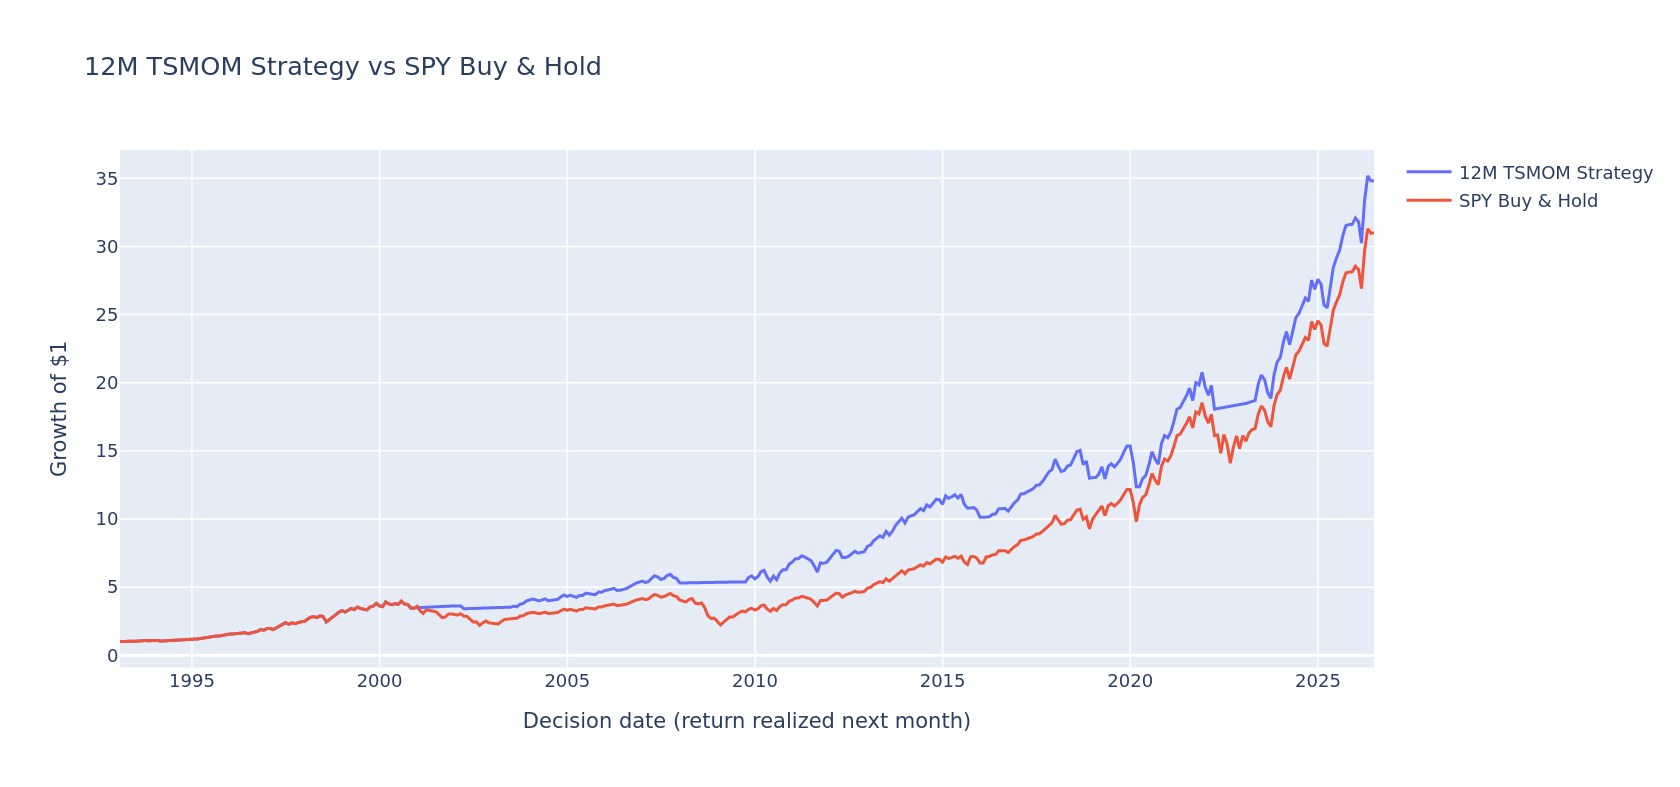

In [37]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=implementation_df.index,
        y=implementation_df["net_strategy_wealth"],
        mode="lines",
        name="12M TSMOM Strategy",
    )
)
fig.add_trace(
    go.Scatter(
        x=implementation_df.index,
        y=implementation_df["spy_buyhold_wealth"],
        mode="lines",
        name="SPY Buy & Hold",
    )
)
fig.update_layout(
    title="12M TSMOM Strategy vs SPY Buy & Hold",
    xaxis_title="Decision date (return realized next month)",
    yaxis_title="Growth of $1",
)
fig.show()


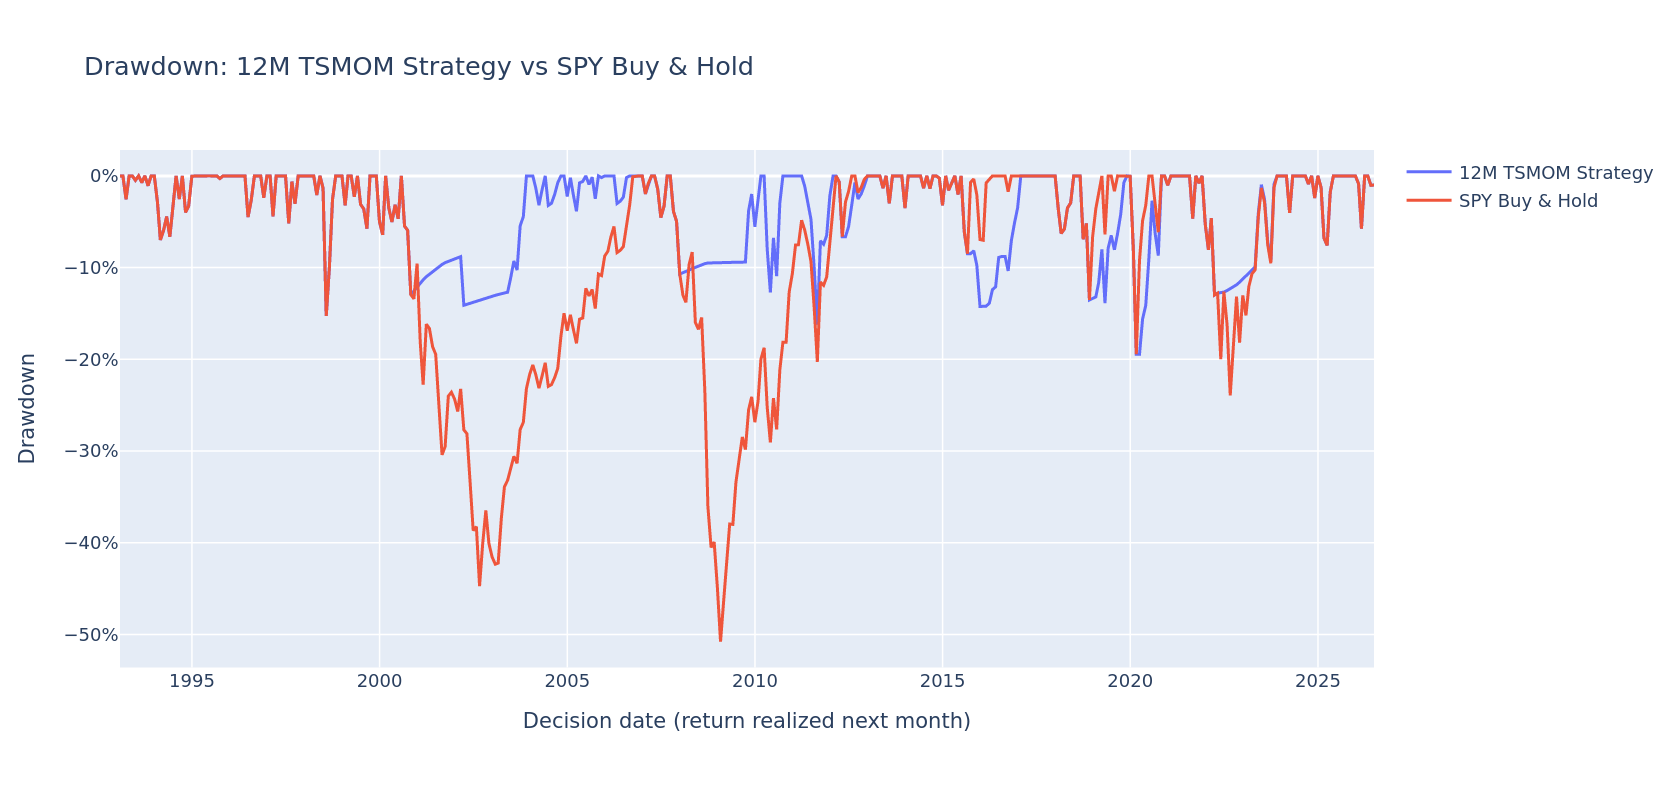

In [38]:
implementation_df["strategy_peak"] = implementation_df["net_strategy_wealth"].cummax()
implementation_df["spy_buyhold_peak"] = implementation_df["spy_buyhold_wealth"].cummax()

implementation_df["strategy_drawdown"] = (
    implementation_df["net_strategy_wealth"] / implementation_df["strategy_peak"]
) - 1
implementation_df["spy_buyhold_drawdown"] = (
    implementation_df["spy_buyhold_wealth"] / implementation_df["spy_buyhold_peak"]
) - 1

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=implementation_df.index,
        y=implementation_df["strategy_drawdown"],
        mode="lines",
        name="12M TSMOM Strategy",
    )
)
fig.add_trace(
    go.Scatter(
        x=implementation_df.index,
        y=implementation_df["spy_buyhold_drawdown"],
        mode="lines",
        name="SPY Buy & Hold",
    )
)
fig.update_layout(
    title="Drawdown: 12M TSMOM Strategy vs SPY Buy & Hold",
    xaxis_title="Decision date (return realized next month)",
    yaxis=dict(title="Drawdown", tickformat=".0%"),
)
fig.show()


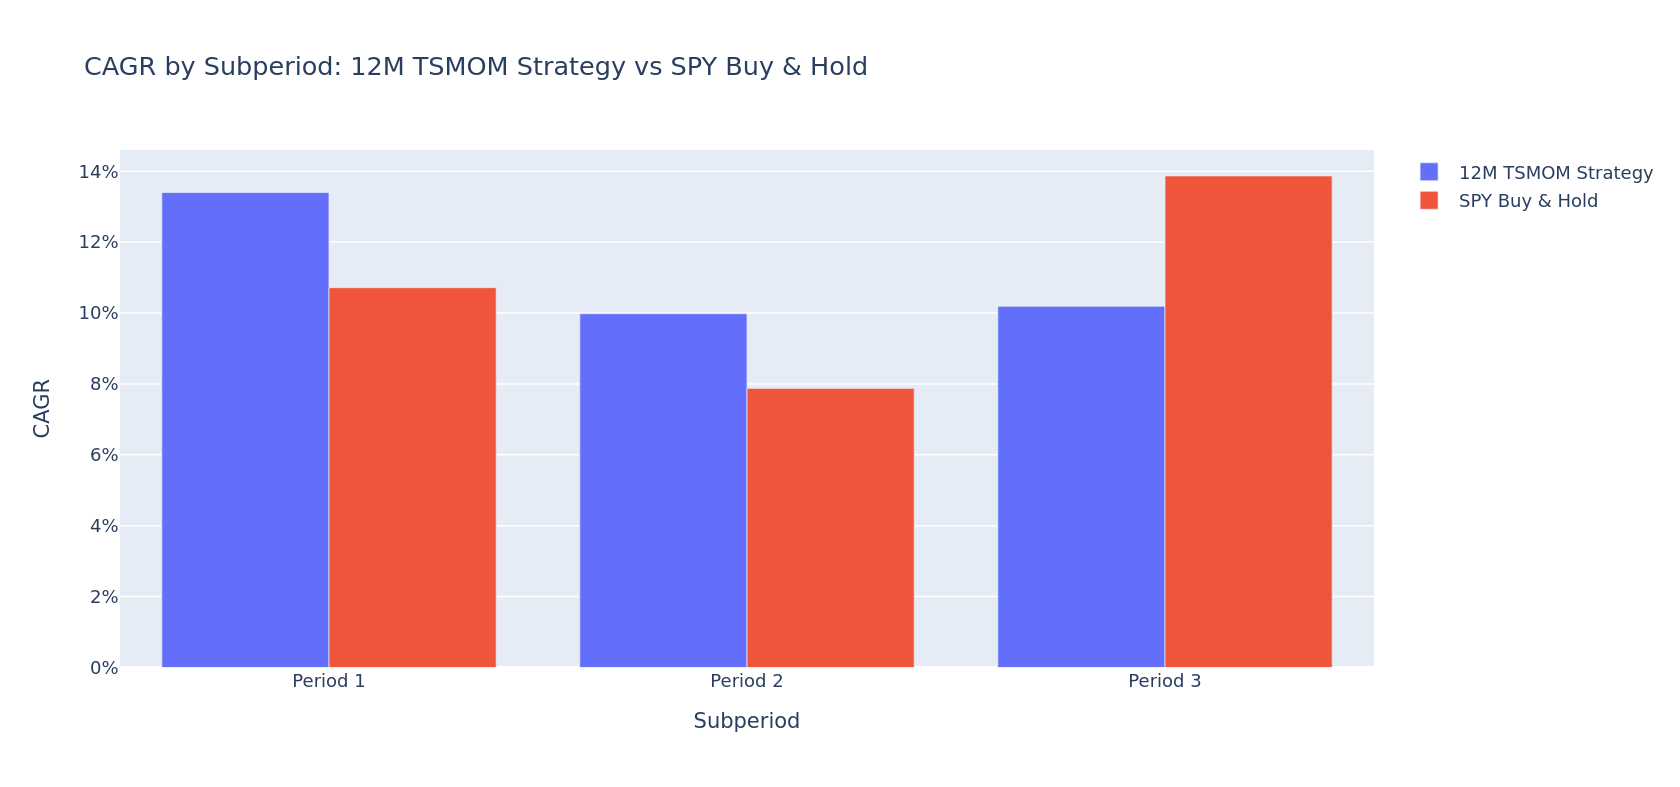

In [39]:
fig = go.Figure()
fig.add_trace(
    go.Bar(x=results_df.index, y=results_df["CAGR_strategy"], name="12M TSMOM Strategy")
)
fig.add_trace(
    go.Bar(x=results_df.index, y=results_df["CAGR_spy_buyhold"], name="SPY Buy & Hold")
)
fig.update_layout(
    title="CAGR by Subperiod: 12M TSMOM Strategy vs SPY Buy & Hold",
    xaxis_title="Subperiod",
    yaxis=dict(title="CAGR", tickformat=".0%"),
)
fig.show()


## 11. Conclusions

The statistical analysis finds a positive return difference after positive 12-month returns, but the effect is not significant after HAC correction. The data therefore do not provide strong evidence of reliable return predictability.

The full-sample SPY backtest has slightly higher CAGR, lower volatility, smaller drawdowns, and a higher Sharpe ratio than SPY buy and hold. The return advantage is not stable over time: the strategy underperforms in CAGR and Sharpe ratio in the most recent subperiod, while still reducing volatility and maximum drawdown.

The strategy's most consistent historical benefit is lower risk. These results do not establish a reliable return advantage or show that the strategy will continue to outperform or underperform.


## 12. Limitations

- There is no fully untouched out-of-sample period.
- The analysis covers only the S&P 500; the SPY implementation starts in 1993.
- Transaction costs are simplified and do not model every execution cost separately. No separate execution delay is included.
- The risk-free series is a cash-return proxy; no specific cash trading instrument is simulated.
- Risk and drawdown measures use monthly observations, so they do not capture intramonth losses. The original running peak starts with the first recorded wealth value rather than a separate initial value of 1.
- The momentum effect is not statistically significant after accounting for time-series dependence.
- Historical performance varies substantially across subperiods.

### Background reading recorded in the original notebook

- Moskowitz, Ooi & Pedersen (2012), *Time Series Momentum*.
- *A Century of Evidence on Trend-Following Investing*.

These readings provide background; this single-index, long-or-cash project is not a replication of either study.
